# PatchTST-VAE Fine-tuning (using pretrained encoder)

In [1]:
## Block 1 — imports + config  
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


class Config:
    csv_path       = "ETTh1.csv"
    seq_len        = 96
    pred_len       = 24
    n_variates     = 7

    patch_len      = 16
    stride         = 8
    d_model        = 128
    n_heads        = 4
    n_layers       = 3
    dropout_p      = 0.1

    z_dim          = 32

    batch_size     = 64
    epochs         = 60
    lr             = 1e-3
    warmup_epochs  = 20
    grad_clip_norm = 5.0

    pretrained_path = "patchtst_pretrained.pth"      # INPUT  (never overwritten)
    ckpt_path       = "patchtst_vae_finetuned.pth"    # OUTPUT (fine-tuned VAE)


cfg = Config()

In [2]:
## Block 2 — data (past + future )
class ETTh1DataModule:
    def __init__(self, cfg):
        self.cfg = cfg

    def load_raw(self):
        df = pd.read_csv(self.cfg.csv_path)
        return df.iloc[:, 1:].values.astype("float32")

    def normalize(self, data):
        n_train = int(0.6 * len(data))
        mean = data[:n_train].mean(axis=0)
        std  = data[:n_train].std(axis=0) + 1e-8
        return (data - mean) / std

    def window(self, data):
        X, Y = [], []
        total = self.cfg.seq_len + self.cfg.pred_len
        for i in range(len(data) - total + 1):
            X.append(data[i : i + self.cfg.seq_len])
            Y.append(data[i + self.cfg.seq_len : i + total])
        return np.stack(X), np.stack(Y)

    def get_loaders(self):
        data = self.normalize(self.load_raw())
        X, Y = self.window(data)

        n = len(X)
        n_train = int(0.6 * n)
        n_val   = int(0.2 * n)

        X_train, Y_train = X[:n_train], Y[:n_train]
        X_val,   Y_val   = X[n_train:n_train+n_val], Y[n_train:n_train+n_val]
        X_test,  Y_test  = X[n_train+n_val:], Y[n_train+n_val:]

        train_set = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(Y_train))
        val_set   = TensorDataset(torch.from_numpy(X_val),   torch.from_numpy(Y_val))
        test_set  = TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(Y_test))

        return (
            DataLoader(train_set, batch_size=self.cfg.batch_size, shuffle=True),
            DataLoader(val_set,   batch_size=self.cfg.batch_size, shuffle=False),
            DataLoader(test_set,  batch_size=self.cfg.batch_size, shuffle=False),
        )


data_module = ETTh1DataModule(cfg)
train_loader, val_loader, test_loader = data_module.get_loaders()

In [3]:
## Block 3 — MultiHeadSelfAttention + TransformerBlock
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout_p=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head  = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, x):
        B, T, _ = x.shape
        Q = self.W_q(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        K = self.W_k(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        V = self.W_v(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)

        scores = (Q @ K.transpose(-2, -1)) / (self.d_head ** 0.5)
        attn   = self.dropout(torch.softmax(scores, dim=-1))

        out = attn @ V
        out = out.transpose(1, 2).contiguous().view(B, T, self.d_model)
        return self.W_o(out)


class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, dropout_p=0.1):
        super().__init__()
        self.attn  = MultiHeadSelfAttention(d_model, n_heads, dropout_p)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout_p),
            nn.Linear(d_model * 4, d_model),
        )
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, x):
        x = x + self.dropout(self.attn(self.norm1(x)))
        x = x + self.dropout(self.ff(self.norm2(x)))
        return x

In [4]:
# Block 4 — PatchTST encoder
class PatchTSTEncoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.n_patches = (cfg.seq_len - cfg.patch_len) // cfg.stride + 1

        self.patch_embed = nn.Linear(cfg.patch_len, cfg.d_model)
        self.pos_embed   = nn.Parameter(torch.randn(1, self.n_patches, cfg.d_model) * 0.02)
        # kept for state_dict compatibility with the pretrained checkpoint (not used here)
        self.mask_token  = nn.Parameter(torch.randn(1, 1, cfg.d_model) * 0.02)

        self.blocks = nn.ModuleList([
            TransformerBlock(cfg.d_model, cfg.n_heads, cfg.dropout_p)
            for _ in range(cfg.n_layers)
        ])

    def patchify(self, x):
        x = x.permute(0, 2, 1)
        return x.unfold(dimension=-1, size=self.cfg.patch_len, step=self.cfg.stride)

    def forward(self, x):
        B, T, D = x.shape
        patches = self.patchify(x)                                        # [B, D, n_patches, patch_len]
        patches = patches.reshape(B * D, self.n_patches, self.cfg.patch_len)
        h = self.patch_embed(patches) + self.pos_embed
        for block in self.blocks:
            h = block(h)
        return h.reshape(B, D, self.n_patches, self.cfg.d_model)

In [5]:
## Block 5 — VAE bottleneck
class VAEBottleneck(nn.Module):
    def __init__(self, cfg, n_patches):
        super().__init__()
        self.cfg = cfg
        flat_dim = cfg.n_variates * n_patches * cfg.d_model
        self.fc_mu     = nn.Linear(flat_dim, cfg.z_dim)
        self.fc_logvar = nn.Linear(flat_dim, cfg.z_dim)

    def reparameterize(self, mu, logvar):
        logvar = torch.clamp(logvar, min=-10.0, max=10.0)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, h):
        h_flat = h.reshape(h.size(0), -1)
        mu     = self.fc_mu(h_flat)
        logvar = self.fc_logvar(h_flat)
        z = self.reparameterize(mu, logvar)
        return z, mu, logvar

In [6]:
## Block 6 — VAE decoder
class VAEDecoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        out_dim = cfg.pred_len * cfg.n_variates
        self.feature_net = nn.Sequential(
            nn.Linear(cfg.z_dim, 256),
            nn.GELU(),
            nn.Dropout(cfg.dropout_p),
            nn.Linear(256, 512),
            nn.GELU(),
            nn.Dropout(cfg.dropout_p),
            nn.Linear(512, out_dim),
        )

    def forward(self, z):
        return self.feature_net(z).view(z.size(0), self.cfg.pred_len, self.cfg.n_variates)

In [7]:
## Block 7 — full PatchTST-VAE
class PatchTST_VAE(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.patchtst   = PatchTSTEncoder(cfg)
        self.bottleneck = VAEBottleneck(cfg, n_patches=self.patchtst.n_patches)
        self.decoder    = VAEDecoder(cfg)

    def forward(self, x_past):
        h = self.patchtst(x_past)
        z, mu, logvar = self.bottleneck(h)
        return self.decoder(z), mu, logvar

    @torch.no_grad()
    def sample_futures(self, x_past, n_samples=10):
        h = self.patchtst(x_past)
        _, mu, logvar = self.bottleneck(h)
        std = torch.exp(0.5 * torch.clamp(logvar, min=-10.0, max=10.0))
        futures = []
        for _ in range(n_samples):
            eps = torch.randn_like(std)
            futures.append(self.decoder(mu + eps * std))
        return torch.stack(futures, dim=0)

In [8]:
## Block 8 — ELBO loss
class ELBOLoss:
    def __init__(self, cfg):
        self.cfg = cfg

    def __call__(self, x_future, x_future_hat, mu, logvar, beta=1.0):
        B = x_future.size(0)
        recon_loss = F.mse_loss(x_future_hat, x_future, reduction="sum") / B
        kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=-1).mean()
        total = recon_loss + beta * kl
        return total, {"recon_loss": recon_loss.item(), "kl": kl.item(), "beta": beta, "total": total.item()}

In [9]:
## Block 9 — Trainer
class Trainer:
    def __init__(self, cfg, model, train_loader, val_loader):
        self.cfg          = cfg
        self.model        = model
        self.train_loader = train_loader
        self.val_loader   = val_loader
        self.loss_fn      = ELBOLoss(cfg)
        self.optimizer    = optim.Adam(model.parameters(), lr=cfg.lr)

        self.train_losses = []
        self.val_losses   = []
        self.best_val_loss = float("inf")

    def _run_epoch(self, loader, beta, training):
        self.model.train() if training else self.model.eval()
        total_loss, n = 0.0, 0
        ctx = torch.enable_grad() if training else torch.no_grad()

        with ctx:
            for x_past, x_future in loader:
                B = x_past.size(0)
                if training:
                    self.optimizer.zero_grad()

                x_future_hat, mu, logvar = self.model(x_past)
                loss, _ = self.loss_fn(x_future, x_future_hat, mu, logvar, beta=beta)

                if training:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=self.cfg.grad_clip_norm)
                    self.optimizer.step()

                total_loss += loss.item() * B
                n += B

        return total_loss / n

    def fit(self):
        for epoch in range(self.cfg.epochs):
            beta = min(1.0, (epoch + 1) / self.cfg.warmup_epochs)

            train_loss = self._run_epoch(self.train_loader, beta, training=True)
            val_loss   = self._run_epoch(self.val_loader,   beta=1.0, training=False)

            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)

            print(f"Epoch {epoch:03d}: beta={beta:.2f}  train={train_loss:.4f}  val={val_loss:.4f}")

            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                torch.save({
                    "model":        self.model.state_dict(),
                    "optimizer":    self.optimizer.state_dict(),
                    "epoch":        epoch,
                    "beta":         beta,
                    "train_losses": self.train_losses,
                    "val_losses":   self.val_losses,
                }, self.cfg.ckpt_path)

In [10]:
# 1. load pretrained encoder
pretrained = torch.load(cfg.pretrained_path, map_location="cpu")
print("pretrained keys:", list(pretrained.keys()))

# 2. build VAE, load encoder weights
patchtst_vae = PatchTST_VAE(cfg)
patchtst_vae.patchtst.load_state_dict(pretrained["encoder"])
print("pretrained encoder loaded.")

# 3. fine-tune (saves to cfg.ckpt_path = 'patchtst_vae_finetuned.pth')
trainer = Trainer(cfg, patchtst_vae, train_loader, val_loader)
trainer.fit()

# 4. save loss history separately
with open("finetune_loss_history.json", "w") as f:
    json.dump({"train": trainer.train_losses, "val": trainer.val_losses}, f)

print(f"Best val loss    : {trainer.best_val_loss:.4f}")
print(f"Fine-tuned model : {cfg.ckpt_path}")

pretrained keys: ['encoder', 'optimizer', 'epoch', 'train_losses', 'val_losses']
pretrained encoder loaded.
Epoch 000: beta=0.05  train=63.5364  val=158.2639
Epoch 001: beta=0.10  train=49.0315  val=133.7182
Epoch 002: beta=0.15  train=46.4060  val=121.5771
Epoch 003: beta=0.20  train=44.8369  val=122.8210
Epoch 004: beta=0.25  train=44.1213  val=110.8750
Epoch 005: beta=0.30  train=43.3541  val=111.4013
Epoch 006: beta=0.35  train=42.9845  val=104.9769
Epoch 007: beta=0.40  train=43.1494  val=101.8158
Epoch 008: beta=0.45  train=42.9593  val=107.8869
Epoch 009: beta=0.50  train=42.9578  val=97.5630
Epoch 010: beta=0.55  train=43.1889  val=100.0754
Epoch 011: beta=0.60  train=43.1372  val=96.5764
Epoch 012: beta=0.65  train=43.4360  val=94.4383
Epoch 013: beta=0.70  train=43.4957  val=96.1363
Epoch 014: beta=0.75  train=43.6606  val=100.5517
Epoch 015: beta=0.80  train=44.1747  val=99.3829
Epoch 016: beta=0.85  train=44.4402  val=94.6119
Epoch 017: beta=0.90  train=44.7214  val=94.0799

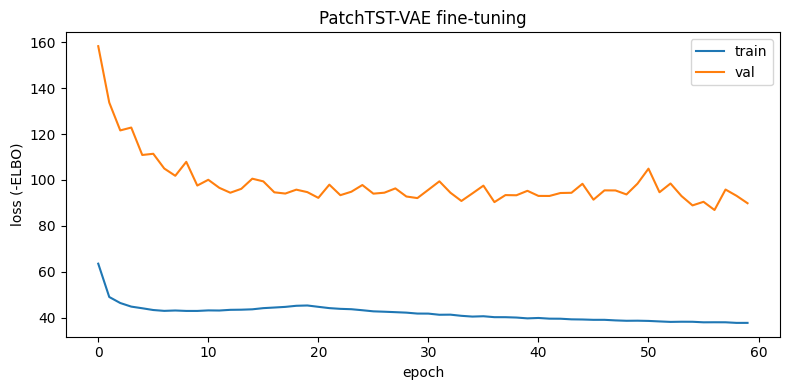

In [11]:
## Point 1 — Loss curve
with open("finetune_loss_history.json") as f:
    history = json.load(f)

plt.figure(figsize=(8, 4))
plt.plot(history["train"], label="train")
plt.plot(history["val"],   label="val")
plt.xlabel("epoch"); plt.ylabel("loss (-ELBO)")
plt.title("PatchTST-VAE fine-tuning")
plt.legend(); plt.tight_layout()
plt.savefig("finetune_loss_curve.png", dpi=150)
plt.show()

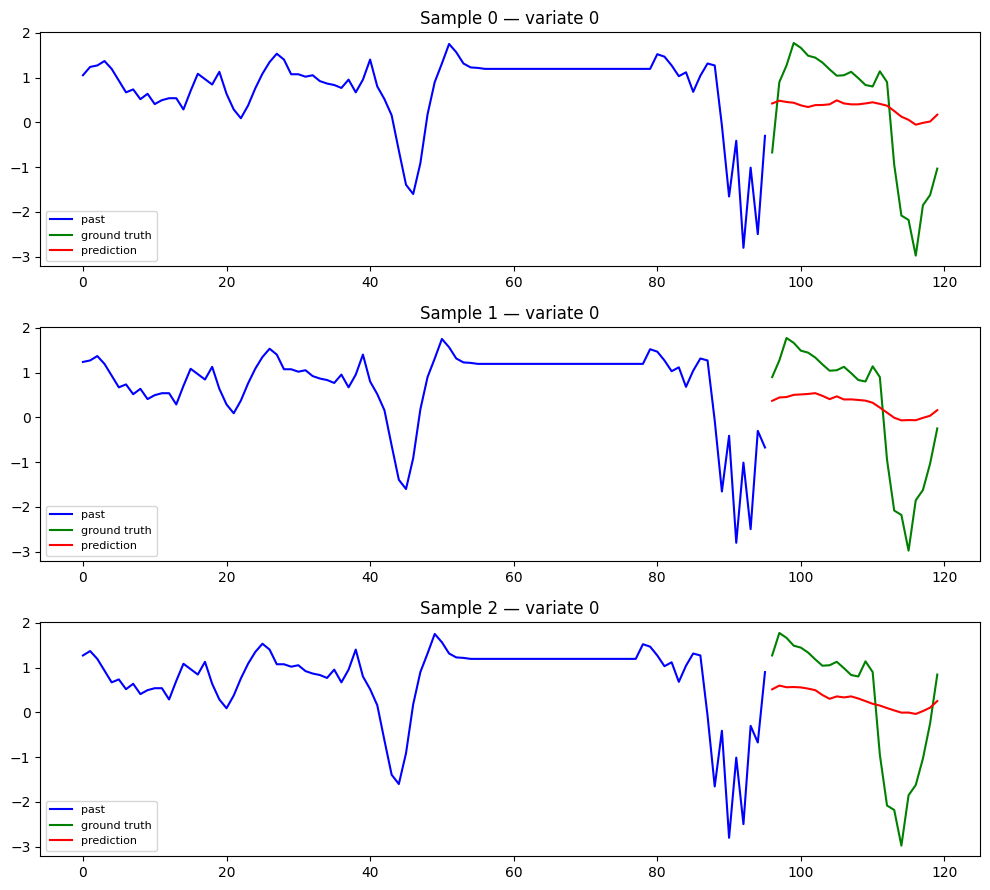

In [12]:
## Point 2 — Point forecast vs ground truth
ckpt = torch.load(cfg.ckpt_path, map_location="cpu")
patchtst_vae = PatchTST_VAE(cfg)
patchtst_vae.load_state_dict(ckpt["model"])
patchtst_vae.eval()

x_past, x_future = next(iter(test_loader))
with torch.no_grad():
    x_future_hat, mu, logvar = patchtst_vae(x_past)

n_show, variate = 3, 0
fig, axes = plt.subplots(n_show, 1, figsize=(10, n_show * 3))
for i in range(n_show):
    axes[i].plot(range(cfg.seq_len), x_past[i, :, variate].numpy(),  label="past",         color="blue")
    axes[i].plot(range(cfg.seq_len, cfg.seq_len+cfg.pred_len), x_future[i, :, variate].numpy(),     label="ground truth", color="green")
    axes[i].plot(range(cfg.seq_len, cfg.seq_len+cfg.pred_len), x_future_hat[i, :, variate].numpy(), label="prediction",   color="red")
    axes[i].legend(fontsize=8); axes[i].set_title(f"Sample {i} — variate {variate}")
plt.tight_layout()
plt.savefig("finetune_point_forecast.png", dpi=150)
plt.show()

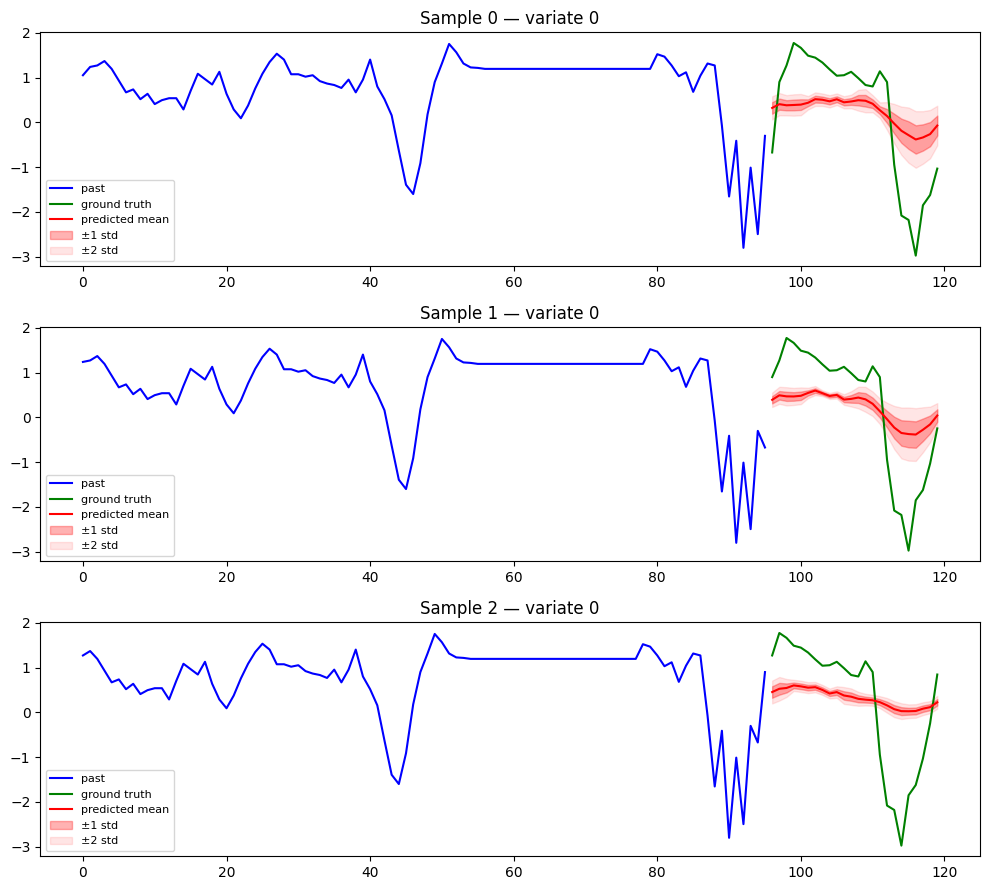

In [13]:
## Point 3 — Probabilistic fan plot
n_samples, n_show, variate = 20, 3, 0

ckpt = torch.load(cfg.ckpt_path, map_location="cpu")
patchtst_vae = PatchTST_VAE(cfg)
patchtst_vae.load_state_dict(ckpt["model"])
patchtst_vae.eval()

x_past, x_future = next(iter(test_loader))
futures = patchtst_vae.sample_futures(x_past, n_samples=n_samples)

fig, axes = plt.subplots(n_show, 1, figsize=(10, n_show * 3))
for i in range(n_show):
    samples = futures[:, i, :, variate].numpy()
    mean, std = samples.mean(axis=0), samples.std(axis=0)

    t_past   = range(cfg.seq_len)
    t_future = range(cfg.seq_len, cfg.seq_len + cfg.pred_len)

    axes[i].plot(t_past,   x_past[i, :, variate].numpy(),   color="blue",  label="past")
    axes[i].plot(t_future, x_future[i, :, variate].numpy(), color="green", label="ground truth")
    axes[i].plot(t_future, mean,   color="red", label="predicted mean")
    axes[i].fill_between(t_future, mean - std,   mean + std,   alpha=0.3, color="red", label="±1 std")
    axes[i].fill_between(t_future, mean - 2*std, mean + 2*std, alpha=0.1, color="red", label="±2 std")
    axes[i].legend(fontsize=8)
    axes[i].set_title(f"Sample {i} — variate {variate}")

plt.tight_layout()
plt.savefig("finetune_probabilistic_forecast.png", dpi=150)
plt.show()

In [15]:
## Point 4 — MSE + MAE on test set
ckpt = torch.load(cfg.ckpt_path, map_location="cpu")
patchtst_vae = PatchTST_VAE(cfg)
patchtst_vae.load_state_dict(ckpt["model"])
patchtst_vae.eval()

preds, targets = [], []
with torch.no_grad():
    for x_past, x_future in test_loader:
        x_future_hat, _, _ = patchtst_vae(x_past)
        preds.append(x_future_hat.numpy())
        targets.append(x_future.numpy())

preds   = np.concatenate(preds,   axis=0)
targets = np.concatenate(targets, axis=0)

mse = float(np.mean((preds - targets) ** 2))
mae = float(np.mean(np.abs(preds - targets)))
print(f"Test MSE : {mse:.4f}")
print(f"Test MAE : {mae:.4f}")

with open("finetune_test_metrics.json", "w") as f:
    json.dump({"mse": mse, "mae": mae}, f, indent=2)

Test MSE : 0.5773
Test MAE : 0.5585


Mean recon loss : 96.9178
Mean KL loss    : 15.5516


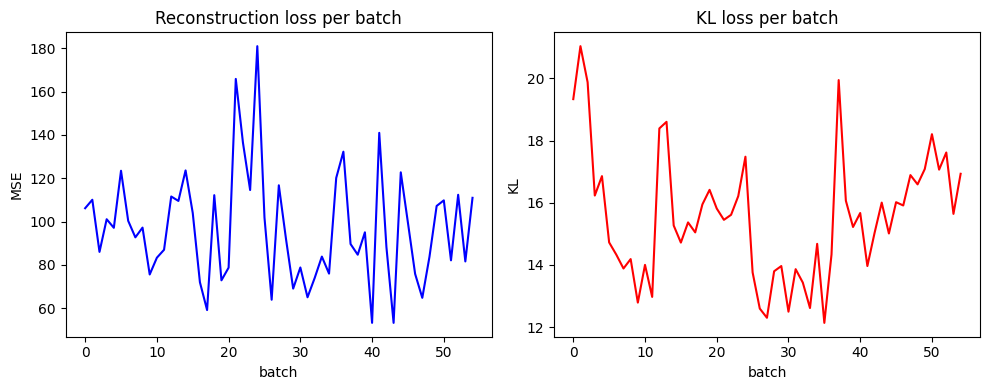

In [16]:
## Point 5 — KL vs reconstruction loss separately
ckpt = torch.load(cfg.ckpt_path, map_location="cpu")
patchtst_vae = PatchTST_VAE(cfg)
patchtst_vae.load_state_dict(ckpt["model"])
patchtst_vae.eval()

loss_fn = ELBOLoss(cfg)
recon_losses, kl_losses = [], []

with torch.no_grad():
    for x_past, x_future in test_loader:
        x_future_hat, mu, logvar = patchtst_vae(x_past)
        _, terms = loss_fn(x_future, x_future_hat, mu, logvar, beta=1.0)
        recon_losses.append(terms["recon_loss"])
        kl_losses.append(terms["kl"])

recon_losses = np.array(recon_losses)
kl_losses    = np.array(kl_losses)
print(f"Mean recon loss : {recon_losses.mean():.4f}")
print(f"Mean KL loss    : {kl_losses.mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(recon_losses, color="blue"); axes[0].set_title("Reconstruction loss per batch")
axes[0].set_xlabel("batch"); axes[0].set_ylabel("MSE")
axes[1].plot(kl_losses,    color="red");  axes[1].set_title("KL loss per batch")
axes[1].set_xlabel("batch"); axes[1].set_ylabel("KL")
plt.tight_layout()
plt.savefig("finetune_kl_vs_recon.png", dpi=150)
plt.show()

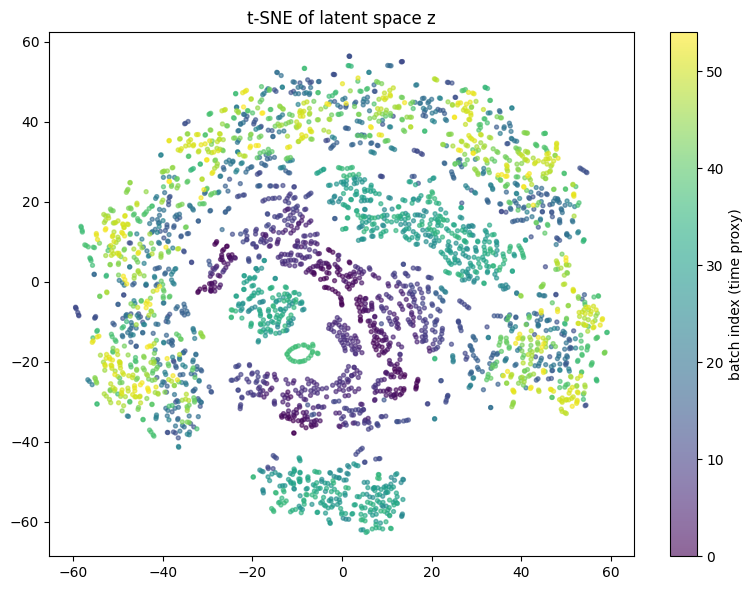

In [17]:
## Point 6 — t-SNE of latent space
from sklearn.manifold import TSNE

ckpt = torch.load(cfg.ckpt_path, map_location="cpu")
patchtst_vae = PatchTST_VAE(cfg)
patchtst_vae.load_state_dict(ckpt["model"])
patchtst_vae.eval()

all_z, all_time = [], []
with torch.no_grad():
    for i, (x_past, x_future) in enumerate(test_loader):
        _, mu, _ = patchtst_vae(x_past)
        all_z.append(mu.numpy())
        all_time.append(np.full(x_past.size(0), i))

all_z    = np.concatenate(all_z,    axis=0)
all_time = np.concatenate(all_time, axis=0)

z_2d = TSNE(n_components=2, random_state=0, perplexity=30).fit_transform(all_z)

plt.figure(figsize=(8, 6))
sc = plt.scatter(z_2d[:, 0], z_2d[:, 1], c=all_time, cmap="viridis", s=8, alpha=0.6)
plt.colorbar(sc, label="batch index (time proxy)")
plt.title("t-SNE of latent space z")
plt.tight_layout()
plt.savefig("finetune_latent_tsne.png", dpi=150)
plt.show()

90% interval coverage: 0.3363  (target: 0.90)
50% interval coverage: 0.1453  (target: 0.50)


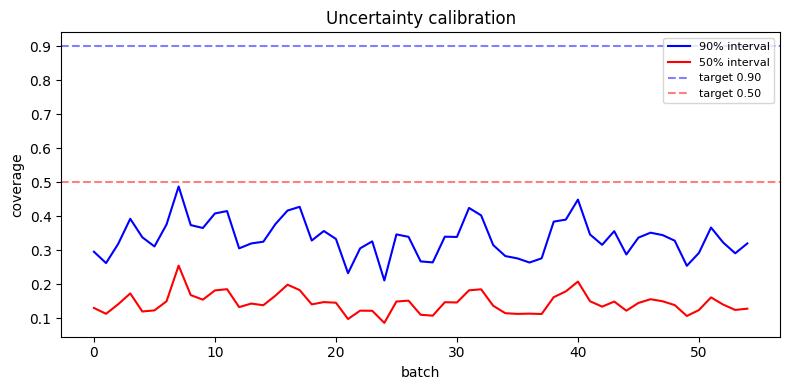

In [18]:
## Point 7 — Uncertainty calibration
ckpt = torch.load(cfg.ckpt_path, map_location="cpu")
patchtst_vae = PatchTST_VAE(cfg)
patchtst_vae.load_state_dict(ckpt["model"])
patchtst_vae.eval()

n_samples = 100
coverage_90, coverage_50 = [], []

with torch.no_grad():
    for x_past, x_future in test_loader:
        futures = patchtst_vae.sample_futures(x_past, n_samples=n_samples)

        lower_90 = futures.quantile(0.05, dim=0)
        upper_90 = futures.quantile(0.95, dim=0)
        lower_50 = futures.quantile(0.25, dim=0)
        upper_50 = futures.quantile(0.75, dim=0)

        coverage_90.append(((x_future >= lower_90) & (x_future <= upper_90)).float().mean().item())
        coverage_50.append(((x_future >= lower_50) & (x_future <= upper_50)).float().mean().item())

print(f"90% interval coverage: {np.mean(coverage_90):.4f}  (target: 0.90)")
print(f"50% interval coverage: {np.mean(coverage_50):.4f}  (target: 0.50)")

plt.figure(figsize=(8, 4))
plt.plot(coverage_90, label="90% interval", color="blue")
plt.plot(coverage_50, label="50% interval", color="red")
plt.axhline(0.90, color="blue", linestyle="--", alpha=0.5, label="target 0.90")
plt.axhline(0.50, color="red",  linestyle="--", alpha=0.5, label="target 0.50")
plt.xlabel("batch"); plt.ylabel("coverage")
plt.title("Uncertainty calibration")
plt.legend(fontsize=8); plt.tight_layout()
plt.savefig("finetune_uncertainty_calibration.png", dpi=150)
plt.show()